# SALES ANALYSIS AND FORECAST USING AI
# Dataset: Adidas Sales

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet
import seaborn as sns
import warnings

# Tắt các cảnh báo không cần thiết và thiết lập hiển thị
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 6]
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

file_path = "Adidas US Sales Datasets.xlsx"

try:
    # 1. Sửa hàm read_excel và thêm skiprows=4 để nhảy qua phần giới thiệu
    # Nếu file đã sạch (không có 4 dòng đầu) thì bỏ skiprows=4 
    df = pd.read_excel(file_path, skiprows=4, engine='openpyxl')

    # Chuẩn hóa tên cột
    df.columns = df.columns.str.strip()

    # 2. Kiểm tra an toàn trước khi lấy [0] để tránh lỗi IndexError
    date_cols = [c for c in df.columns if "date" in c.lower()]
    sales_cols = [c for c in df.columns if "sale" in c.lower() or "revenue" in c.lower()]

    if not date_cols or not sales_cols:
        print("Lỗi: Không tìm thấy cột Ngày hoặc Doanh thu. Hãy kiểm tra lại skiprows!")
    else:
        date_col = date_cols[0]
        sales_col = sales_cols[0]

        # Định dạng ngày tháng
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")

        # Xử lý cột doanh thu (Dùng regex để xóa sạch ký tự lạ)
        df[sales_col] = (
            df[sales_col]
            .astype(str)
            .str.replace(r'[$, ]', '', regex=True)
        )
        df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")

        # Giới hạn giá trị dưới của doanh thu không âm để xử lý ngoại lai (Outliers)
        df[sales_col] = df[sales_col].clip(lower=0)

        # Đổi tên cột chuẩn
        df.rename(columns={date_col: "Invoice Date", sales_col: "Total Sales"}, inplace=True)
        
        if "SalesMethod" in df.columns: 
            df.rename(columns={"SalesMethod": "Sales Method"}, inplace=True)

        # Xóa dòng rỗng (nếu có)
        df = df.dropna(subset=["Invoice Date", "Total Sales"])

        # Tạo các cột thời gian
        df["Year"] = df["Invoice Date"].dt.year
        df["Month"] = df["Invoice Date"].dt.to_period("M")
        df["Quarter"] = df["Invoice Date"].dt.to_period("Q")

        print("\n=== THỐNG KÊ MÔ TẢ DỮ LIỆU ===")
        print(df.describe())

        print("\n=== THÔNG TIN DỮ LIỆU ===")
        print(df.info())

        print("\n=== SỐ LƯỢNG DÒNG & CỘT ===")
        print(df.shape)

        print("Dữ liệu đã sẵn sàng!")
        print(df.head())

except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")
df.head()


=== THỐNG KÊ MÔ TẢ DỮ LIỆU ===
       Unnamed: 0   Retailer ID                   Invoice Date  \
count         0.0  9.648000e+03                           9648   
mean          NaN  1.173850e+06  2021-05-10 15:20:44.776119296   
min           NaN  1.128299e+06            2020-01-01 00:00:00   
25%           NaN  1.185732e+06            2021-02-17 00:00:00   
50%           NaN  1.185732e+06            2021-06-04 00:00:00   
75%           NaN  1.185732e+06            2021-09-16 00:00:00   
max           NaN  1.197831e+06            2021-12-31 00:00:00   
std           NaN  2.636038e+04                            NaN   

       Price per Unit   Units Sold    Total Sales  Operating Profit  \
count     9648.000000  9648.000000    9648.000000       9648.000000   
mean        45.216625   256.930037   93273.437500      34425.244761   
min          7.000000     0.000000       0.000000          0.000000   
25%         35.000000   106.000000    4254.500000       1921.752500   
50%         45.000

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Year,Month,Quarter
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store,2020,2020-01,2020Q1
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store,2020,2020-01,2020Q1
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store,2020,2020-01,2020Q1
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store,2020,2020-01,2020Q1
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store,2020,2020-01,2020Q1


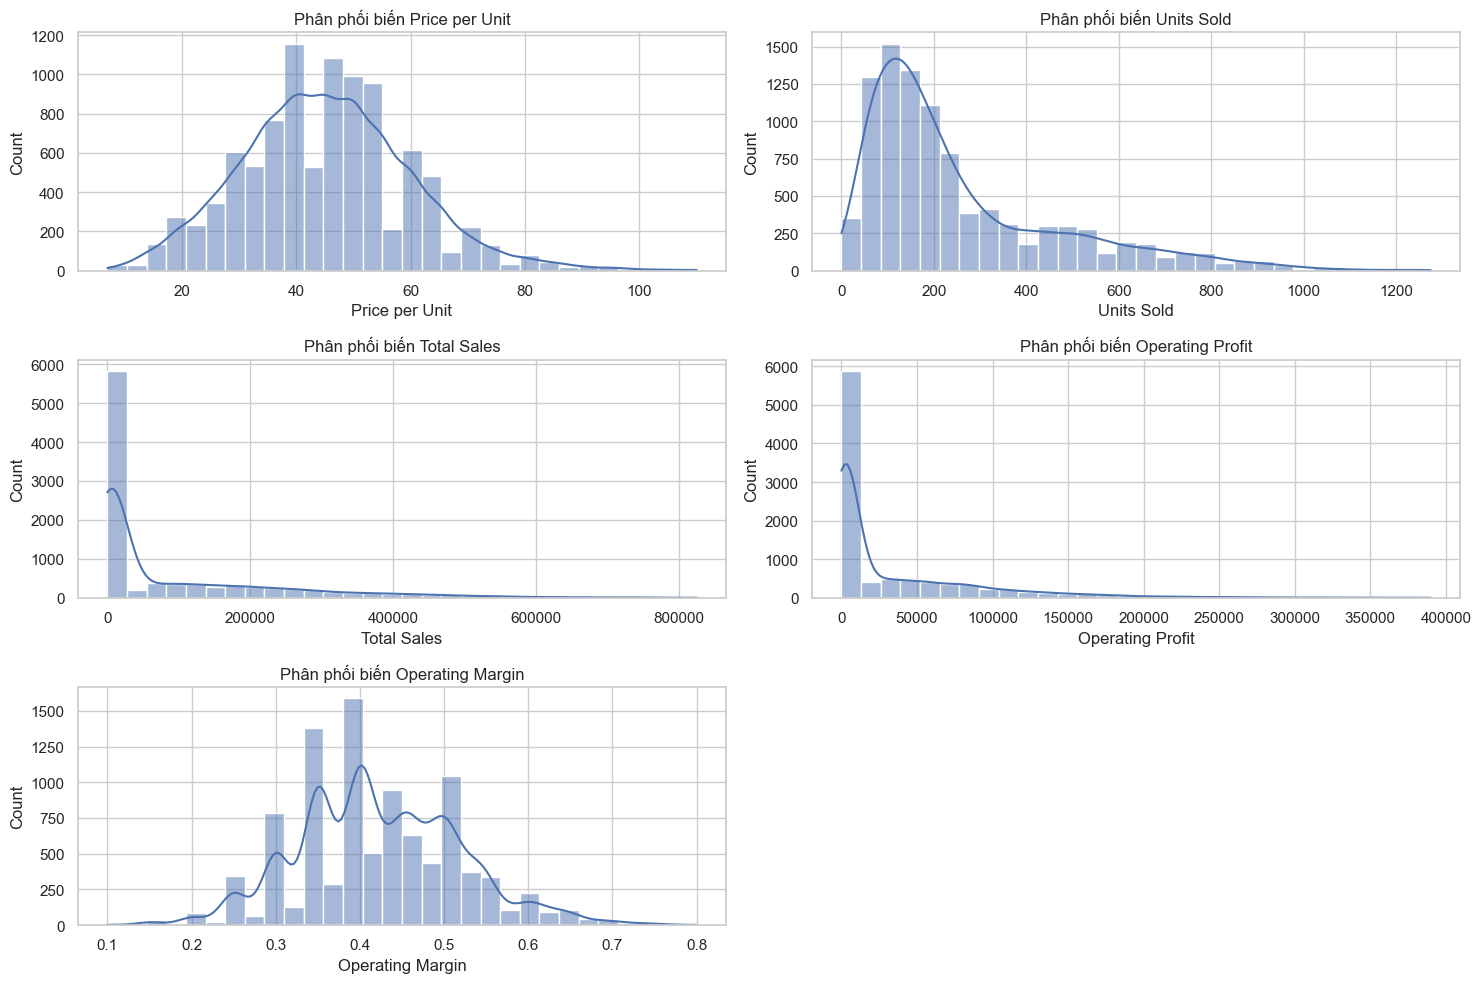

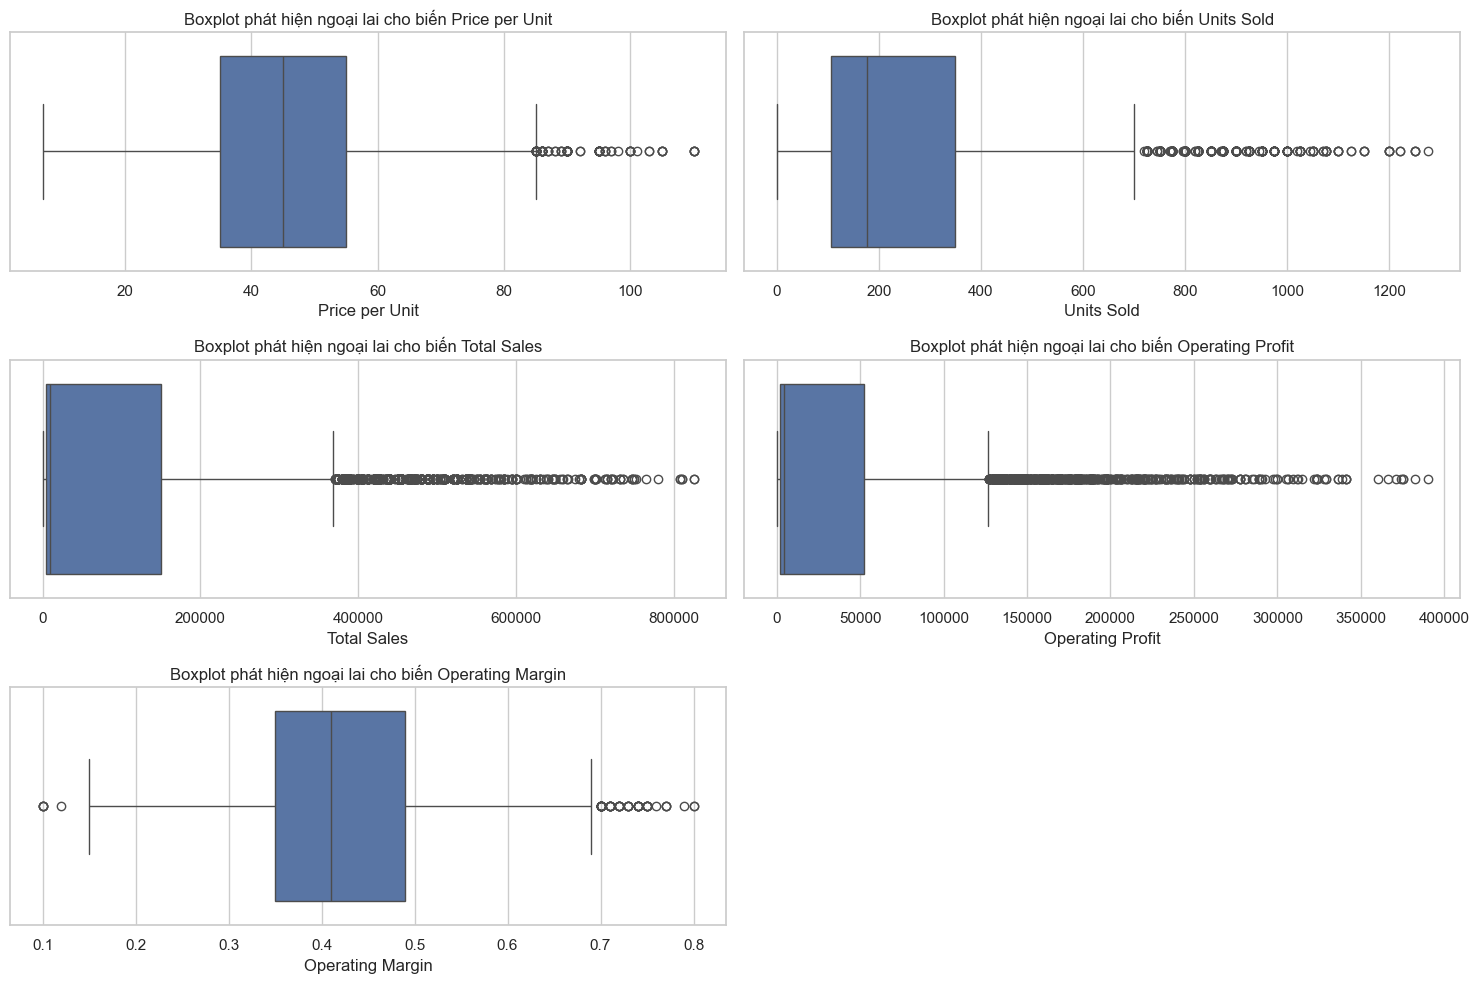

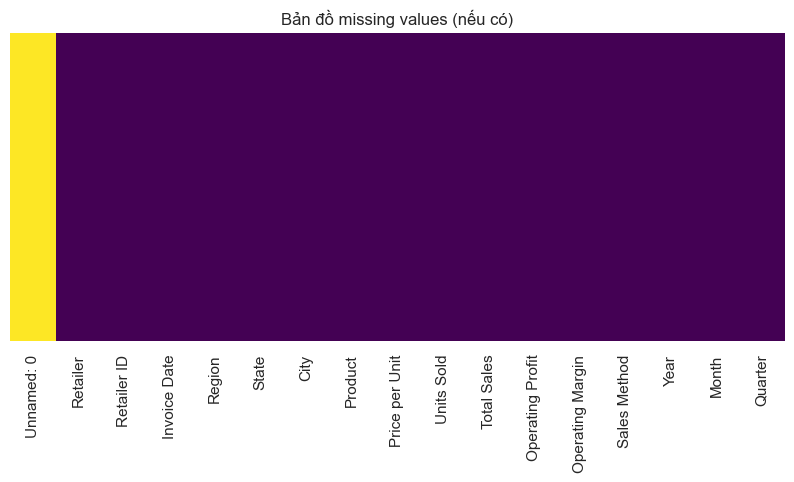

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Biểu đồ phân phối (Histogram) cho biến số quan trọng
num_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Phân phối biến {col}')
plt.tight_layout()
plt.show()

# 2. Biểu đồ Boxplot để phát hiện outliers cho cùng các biến trên
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot phát hiện ngoại lai cho biến {col}')
plt.tight_layout()
plt.show()

# 3. Kiểm tra missing values bằng heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Bản đồ missing values (nếu có)')
plt.show()


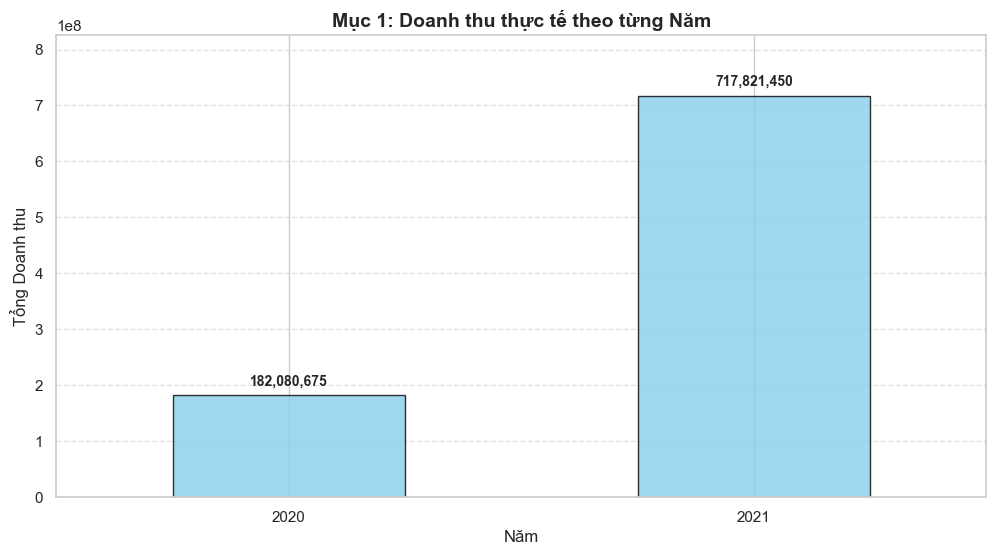

In [4]:
# Tính tổng doanh thu theo năm
yearly_sales = df.groupby("Year")["Total Sales"].sum()

# Vẽ biểu đồ và gán vào biến ax để điều khiển
ax = yearly_sales.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)

# --- PHẦN THÊM SỐ TRÊN ĐẦU CỘT ---
# fmt='{:,.0f}' giúp thêm dấu phẩy ngăn cách hàng nghìn (ví dụ: 1,000,000)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5, fontsize=10, fontweight='bold')

# Tăng giới hạn trục Y thêm 15% để con số không bị dính vào mép trên biểu đồ
plt.ylim(0, yearly_sales.max() * 1.15)

plt.title("Mục 1: Doanh thu thực tế theo từng Năm", fontsize=14, fontweight='bold')
plt.ylabel("Tổng Doanh thu")
plt.xlabel("Năm")
plt.xticks(rotation=0) # Cho năm nằm ngang cho dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.6) # Thêm lưới ngang mờ

plt.show()

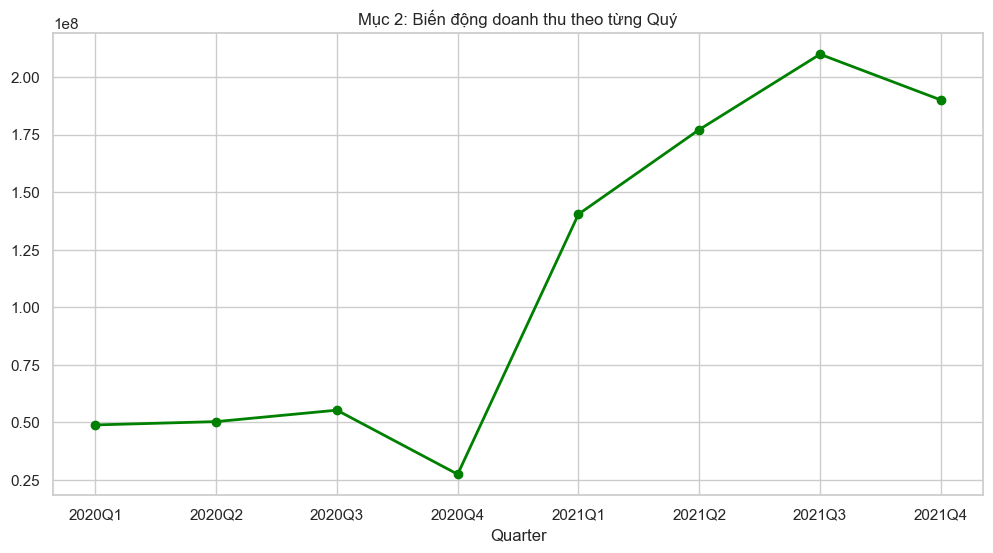

In [5]:
q_sales = df.groupby("Quarter")["Total Sales"].sum()
q_sales.index = q_sales.index.astype(str)
q_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title("Mục 2: Biến động doanh thu theo từng Quý")
plt.show()

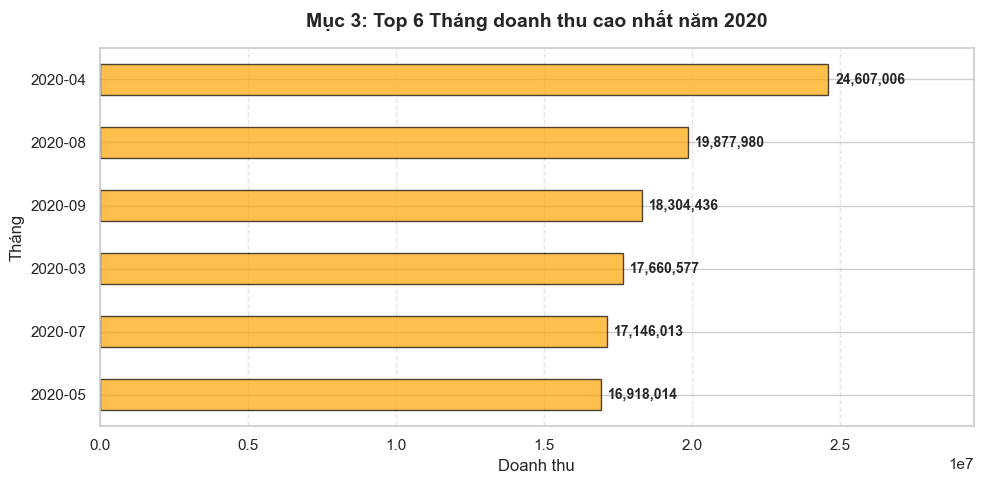

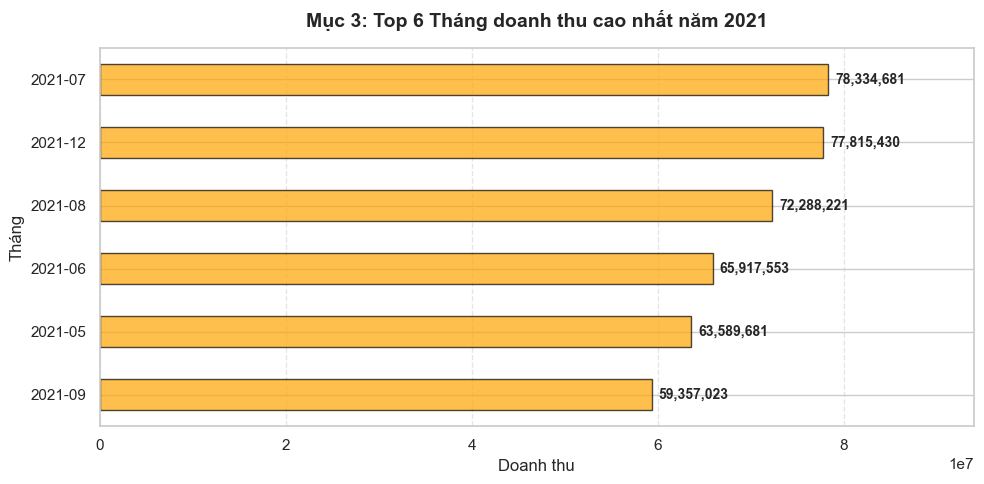

In [6]:
years = sorted(df["Year"].unique())

for y in years:
    # 1. Lọc và tính toán dữ liệu
    data = df[df["Year"] == y].groupby("Month")["Total Sales"].sum().sort_values(ascending=False).head(6)
    data.index = data.index.astype(str)
    
    # 2. Vẽ biểu đồ
    plt.figure(figsize=(10, 5))
    # Gán vào biến ax để điều khiển nhãn
    ax = data.plot(kind='barh', color='orange', edgecolor='black', alpha=0.7)
    
    # --- PHẦN THÊM SỐ BÊN PHẢI CỘT ---
    # padding=5 để đẩy chữ ra xa đầu cột một chút
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5, fontsize=10, fontweight='bold')
    
    # 3. Trang trí
    plt.title(f"Mục 3: Top 6 Tháng doanh thu cao nhất năm {y}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Doanh thu")
    plt.ylabel("Tháng")
    
    # Nới rộng trục X để con số không bị mất khi nằm ngoài cùng bên phải
    plt.xlim(0, data.max() * 1.2) 
    
    plt.gca().invert_yaxis() # Giữ tháng cao nhất ở trên cùng
    plt.grid(axis='x', linestyle='--', alpha=0.5) # Thêm lưới đứng mờ
    plt.tight_layout()
    plt.show()

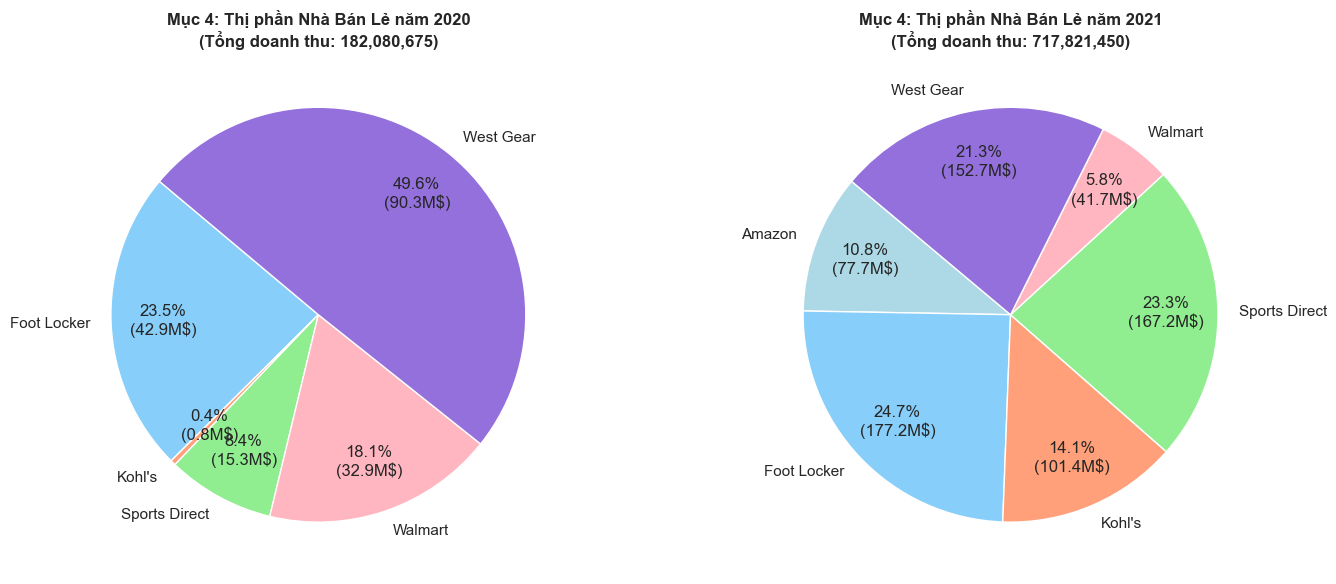

In [7]:
# 1. Định nghĩa bảng màu cố định cho từng Retailer
# Thay đổi mã màu Hex tùy ý tại đây
color_map = {
    'West Gear': '#9370DB',      # Tím trung bình
    'Foot Locker': '#87CEFA',    # Xanh da trời
    'Walmart': '#FFB6C1',        # Hồng nhạt
    'Sports Direct': '#90EE90',  # Xanh lá nhạt
    'Kohl\'s': '#FFA07A',        # Cam san hô
    'Amazon': '#ADD8E6'          # Xanh dương nhạt
}

# 2. Vẽ biểu đồ
fig, axes = plt.subplots(1, len(years), figsize=(15, 6))

for i, y in enumerate(years):
    # Lấy dữ liệu theo năm
    data = df[df["Year"] == y].groupby("Retailer")["Total Sales"].sum()
    total_y = data.sum()
    # --- ĐOẠN QUAN TRỌNG: Lấy danh sách màu dựa theo đúng thứ tự Retailer trong 'data' ---
    current_colors = [color_map.get(retailer, '#CCCCCC') for retailer in data.index]
    
    # Vẽ Pie Chart với tham số colors đã cố định
    axes[i].pie(data, labels=data.index, autopct=lambda pct: f'{pct:.1f}%\n({pct*total_y/100/1e6:.1f}M$)', startangle=140, colors=current_colors,pctdistance=0.75,
    labeldistance=1.1)

    axes[i].set_title(f"Mục 4: Thị phần Nhà Bán Lẻ năm {y}\n(Tổng doanh thu: {total_y:,.0f})", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

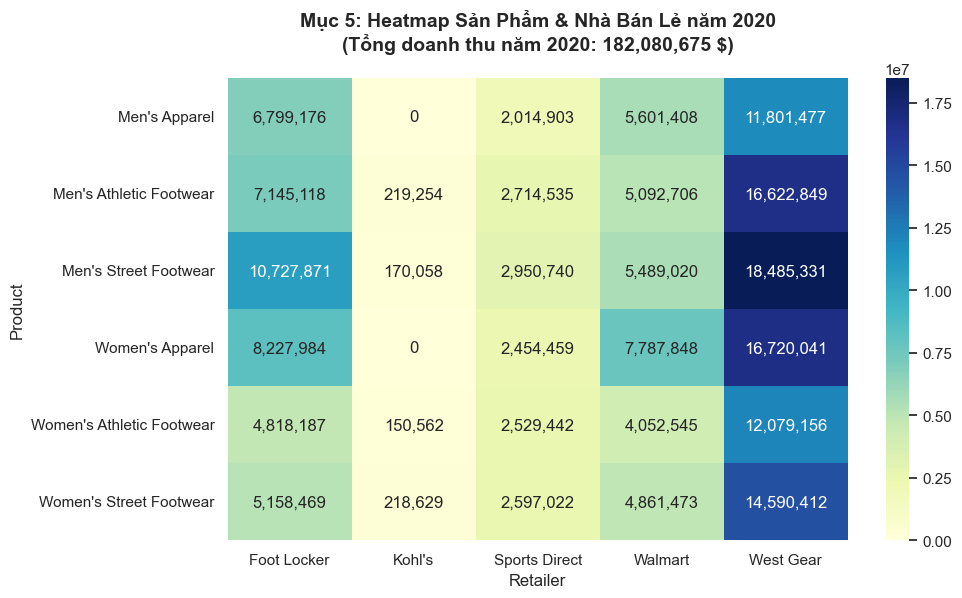

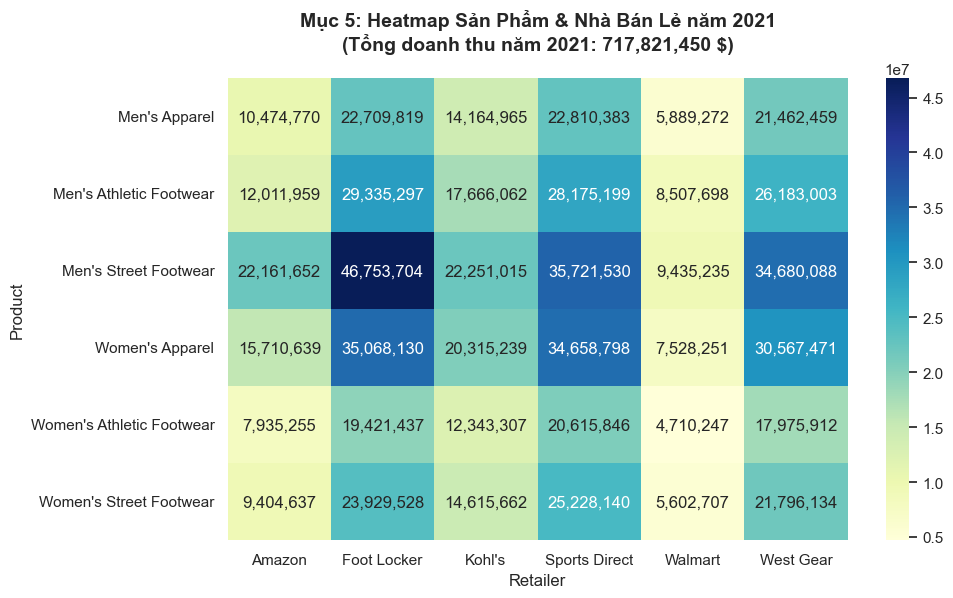

In [8]:
for y in years:
    pivot = pd.pivot_table(df[df["Year"] == y], values="Total Sales", index="Product", columns="Retailer", aggfunc="sum").fillna(0)
    total_year_sales = pivot.values.sum()
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu")
    plt.title(f"Mục 5: Heatmap Sản Phẩm & Nhà Bán Lẻ năm {y}\n(Tổng doanh thu năm {y}: {total_year_sales:,.0f} $)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.show()

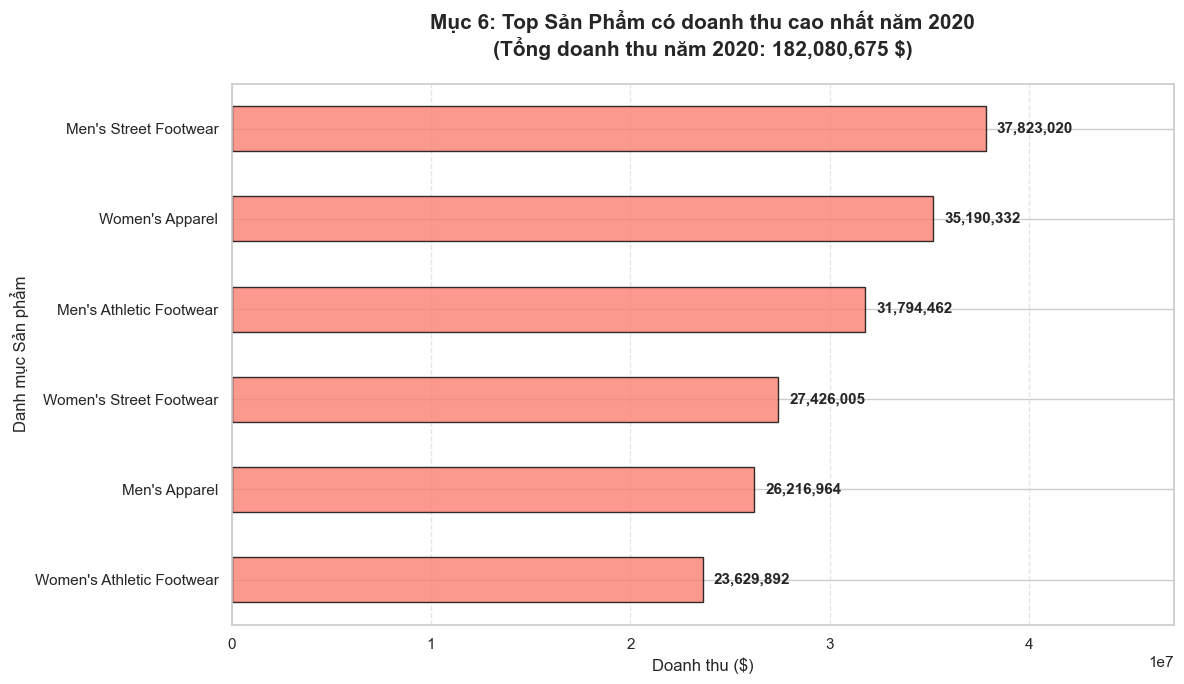

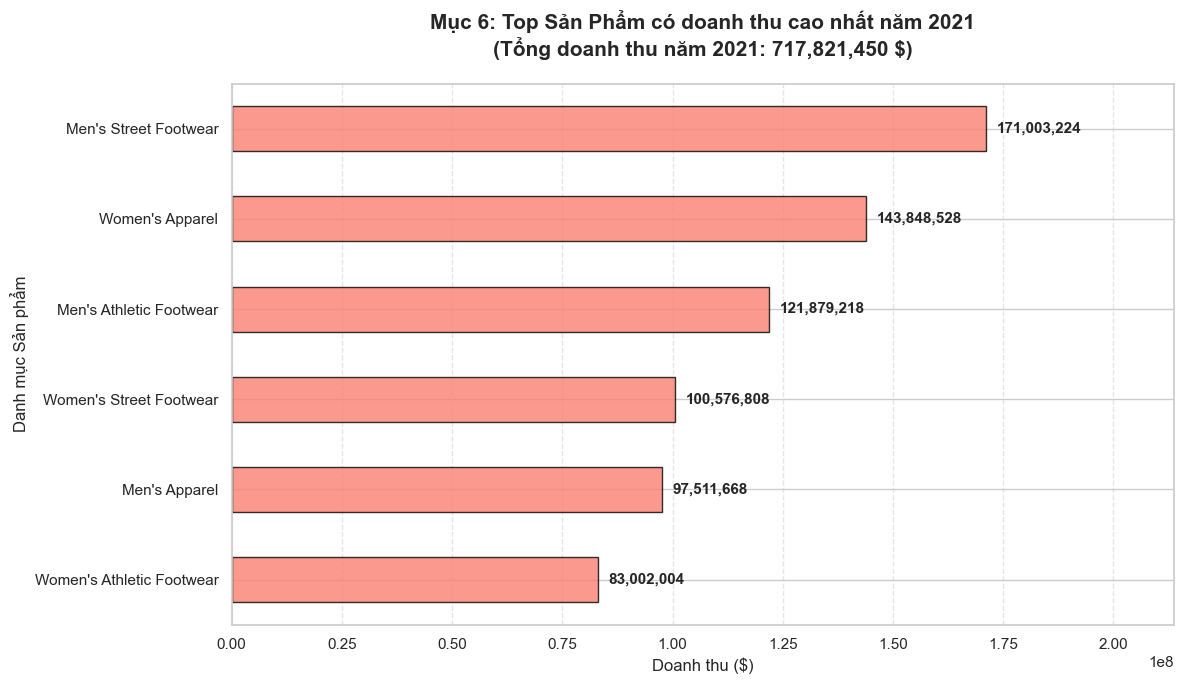

In [9]:
# Lấy danh sách các năm duy nhất từ dữ liệu
years = sorted(df["Year"].unique())

for y in years:
    # 1. Lọc dữ liệu theo năm và tính toán doanh thu theo Sản phẩm
    year_data = df[df["Year"] == y]
    product_sales_year = year_data.groupby("Product")["Total Sales"].sum().sort_values(ascending=True)
    
    # Tính tổng doanh thu của riêng năm đó
    total_y_sales = product_sales_year.sum()
    
    # 2. Vẽ biểu đồ cột ngang cho năm y
    plt.figure(figsize=(12, 7))
    ax = product_sales_year.plot(kind='barh', color='salmon', edgecolor='black', alpha=0.8)
    
    # --- PHẦN THÊM SỐ BÊN PHẢI CỘT ---
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=8, fontsize=11, fontweight='bold')
    
    # 3. Trang trí biểu đồ
    plt.title(f"Mục 6: Top Sản Phẩm có doanh thu cao nhất năm {y}\n(Tổng doanh thu năm {y}: {total_y_sales:,.0f} $)", 
              fontsize=15, fontweight='bold', pad=20)
    
    plt.xlabel("Doanh thu ($)")
    plt.ylabel("Danh mục Sản phẩm")
    
    # Nới rộng trục X khoảng 25% để nhãn số không bị tràn
    plt.xlim(0, product_sales_year.max() * 1.25)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5) 
    plt.tight_layout()
    plt.show()

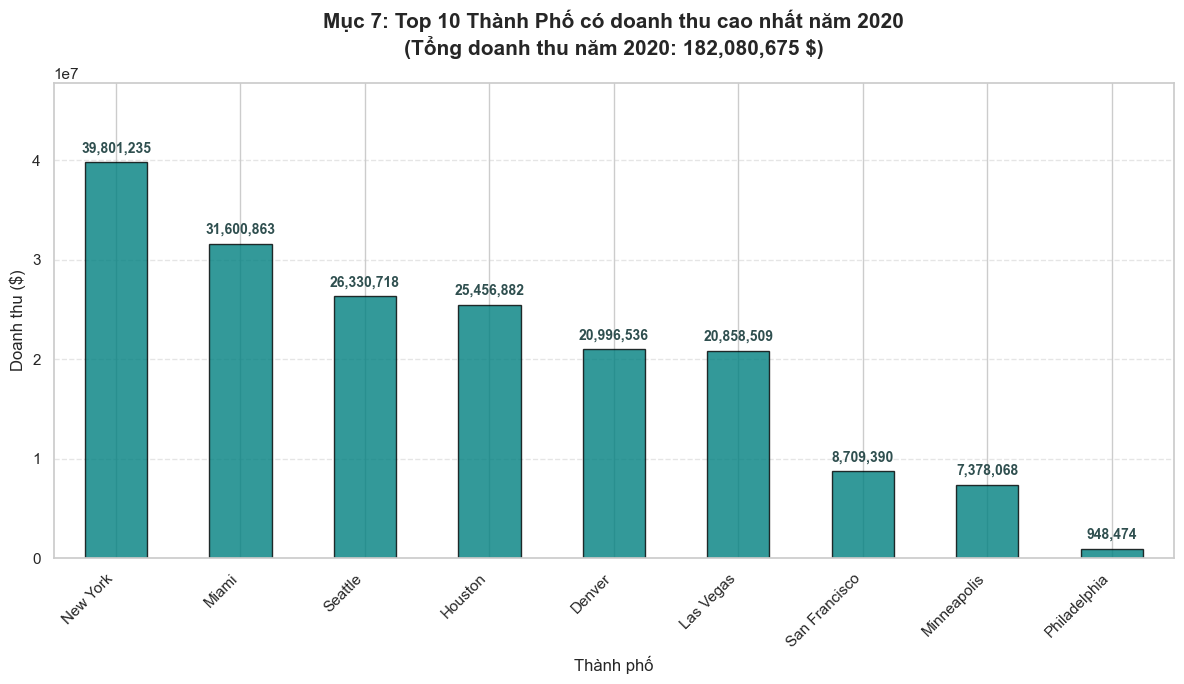

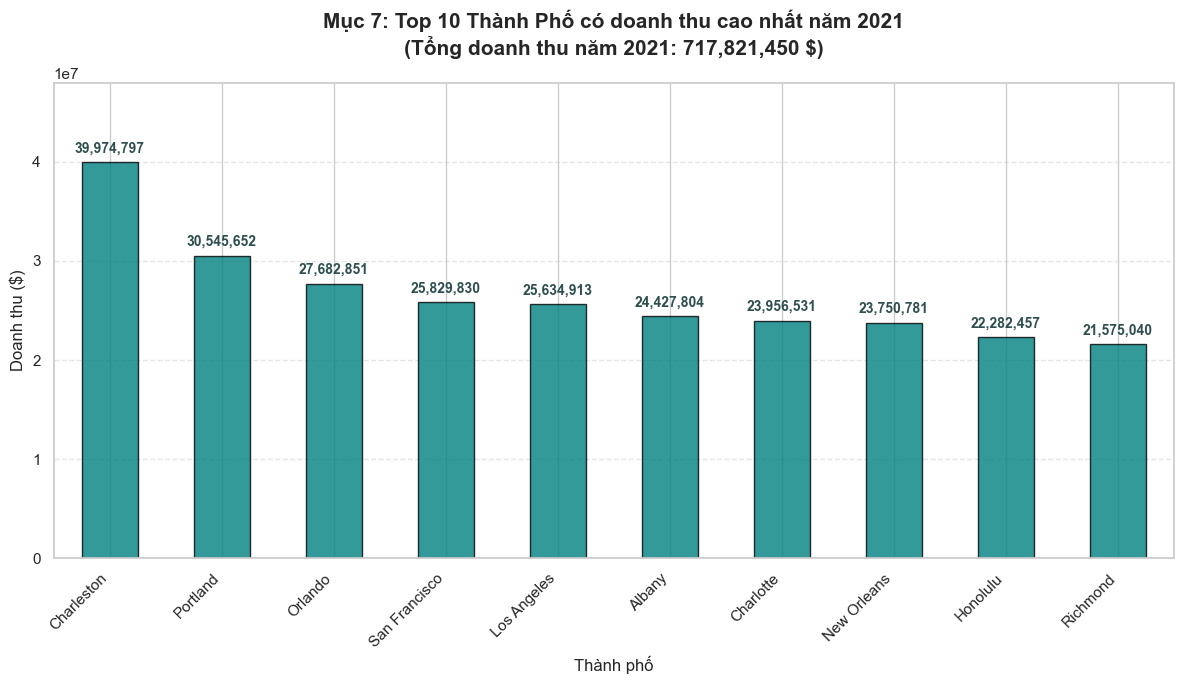

In [10]:
# Lặp qua từng năm để vẽ biểu đồ riêng biệt
for y in years:
    # 1. Lọc dữ liệu theo năm
    year_df = df[df["Year"] == y]
    
    # 2. Tính toán Top 10 thành phố và tổng doanh thu của riêng năm đó
    city_sales_year = year_df.groupby("City")["Total Sales"].sum().sort_values(ascending=False).head(10)
    total_y_sales = year_df["Total Sales"].sum()

    # 3. Vẽ biểu đồ cột đứng
    plt.figure(figsize=(12, 7))
    ax = city_sales_year.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)

    # --- THÊM NHÃN SỐ TRÊN ĐỈNH CỘT ---
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5, fontsize=10, fontweight='bold', color='darkslategray')

    # 4. Trang trí biểu đồ
    plt.title(f"Mục 7: Top 10 Thành Phố có doanh thu cao nhất năm {y}\n(Tổng doanh thu năm {y}: {total_y_sales:,.0f} $)", 
              fontsize=15, fontweight='bold', pad=20)
    
    plt.ylabel("Doanh thu ($)")
    plt.xlabel("Thành phố")

    # Nới rộng trục Y để nhãn không bị chạm mép trên
    plt.ylim(0, city_sales_year.max() * 1.2)

    # Xoay tên thành phố 45 độ để dễ đọc
    plt.xticks(rotation=45, ha='right') 

    plt.grid(axis='y', linestyle='--', alpha=0.5) 
    plt.tight_layout()
    plt.show()

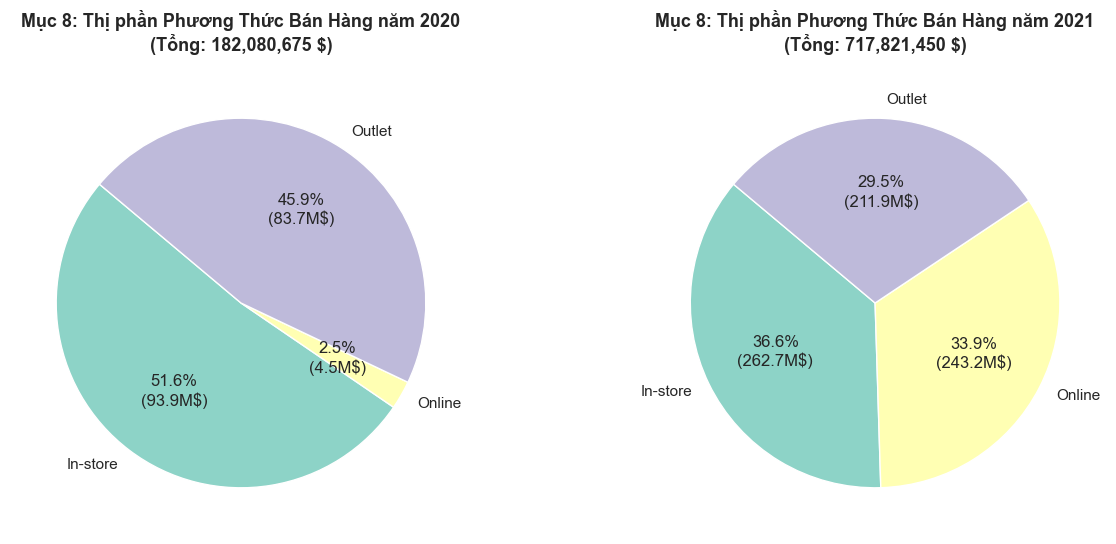

In [11]:
fig, axes = plt.subplots(1, len(years), figsize=(15, 6))
for i, y in enumerate(years):
    data = df[df["Year"] == y].groupby("Sales Method")["Total Sales"].sum()
    total_y = data.sum()
    axes[i].pie(data, labels=data.index, autopct=lambda pct: f'{pct:.1f}%\n({pct*total_y/100/1e6:.1f}M$)', startangle=140, colors=sns.color_palette("Set3"))
    axes[i].set_title(f"Mục 8: Thị phần Phương Thức Bán Hàng năm {y}\n(Tổng: {total_y:,.0f} $)", 
                      fontsize=13, fontweight='bold', pad=15)
plt.show()

                       holiday         ds  lower_window  upper_window
0                New_Year_2020 2020-01-01             0             1
1   Martin_Luther_King_Jr_2020 2020-01-20             0             1
2          Presidents_Day_2020 2020-02-17             0             1
3            Memorial_Day_2020 2020-05-25             0             1
4        Independence_Day_2020 2020-07-04             0             1
5               Labor_Day_2020 2020-09-07             0             1
6            Columbus_Day_2020 2020-10-12             0             1
7            Veterans_Day_2020 2020-11-11             0             1
8            Thanksgiving_2020 2020-11-26             0             1
9            Black_Friday_2020 2020-11-27             0             1
10           Cyber_Monday_2020 2020-11-30             0             1
11              Christmas_2020 2020-12-25             0             1
12               New_Year_2021 2021-01-01             0             1
13  Martin_Luther_Ki

12:18:44 - cmdstanpy - INFO - Chain [1] start processing
12:18:45 - cmdstanpy - INFO - Chain [1] done processing


MAE (sai số trung bình): 1.5092
RMSE: 1.7536
MAPE: 10.81%


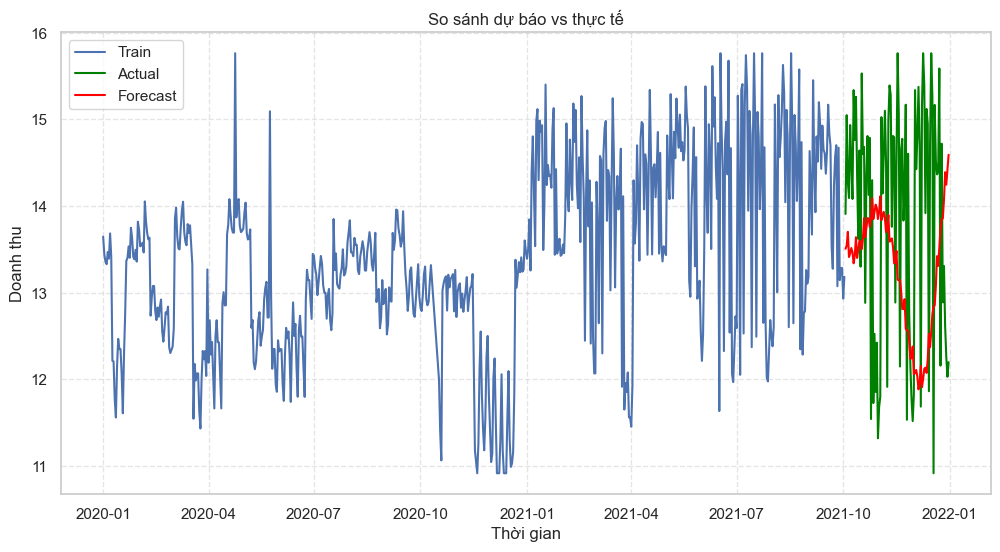

12:18:46 - cmdstanpy - INFO - Chain [1] start processing
12:18:47 - cmdstanpy - INFO - Chain [1] done processing


Mô hình AI đã huấn luyện xong.


In [12]:

# Chuẩn bị dữ liệu cho Prophet (ds: date, y: value)
ts = df.groupby("Invoice Date")["Total Sales"].sum().reset_index()
ts.columns = ["ds","y"]

# Gộp theo tuần
ts_weekly = df.resample('W', on='Invoice Date')['Total Sales'].sum().reset_index()
ts_weekly.columns = ['ds', 'y']

# Gộp theo tháng
ts_monthly = df.resample('M', on='Invoice Date')['Total Sales'].sum().reset_index()
ts_monthly.columns = ['ds', 'y']

# Trị giá trị ngoại lai
# --------------------------
lower_bound = ts['y'].quantile(0.01)
upper_bound = ts['y'].quantile(0.99)
ts['y'] = ts['y'].clip(lower=lower_bound, upper=upper_bound)

# Log-transform (nếu doanh thu có biến động lớn)
# --------------------------
ts['y'] = np.log1p(ts['y'])  # log1p để tránh log(0)

# ==============================
# CHIA TRAIN / TEST + ĐÁNH GIÁ
# ==============================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Chia dữ liệu (90 ngày cuối làm test)
train = ts[:-90]
test = ts[-90:]

# Holidays 
# -----------------------------
import pandas as pd

holidays = pd.DataFrame({
    'holiday': [
        # 2020
        'New_Year_2020', 'Martin_Luther_King_Jr_2020', 'Presidents_Day_2020',
        'Memorial_Day_2020', 'Independence_Day_2020', 'Labor_Day_2020',
        'Columbus_Day_2020', 'Veterans_Day_2020', 'Thanksgiving_2020', 'Black_Friday_2020', 'Cyber_Monday_2020', 'Christmas_2020',
        # 2021
        'New_Year_2021', 'Martin_Luther_King_Jr_2021', 'Presidents_Day_2021',
        'Memorial_Day_2021', 'Independence_Day_2021', 'Labor_Day_2021',
        'Columbus_Day_2021', 'Veterans_Day_2021', 'Thanksgiving_2021', 'Black_Friday_2021', 'Cyber_Monday_2021', 'Christmas_2021'
    ],
    'ds': pd.to_datetime([
        # 2020
        '2020-01-01', '2020-01-20', '2020-02-17', '2020-05-25', '2020-07-04',
        '2020-09-07', '2020-10-12', '2020-11-11', '2020-11-26', '2020-11-27', '2020-11-30', '2020-12-25',
        # 2021
        '2021-01-01', '2021-01-18', '2021-02-15', '2021-05-31', '2021-07-04',
        '2021-09-06', '2021-10-11', '2021-11-11', '2021-11-25', '2021-11-26', '2021-11-29', '2021-12-25'
    ]),
    'lower_window': 0,
    'upper_window': 1
})

print(holidays)

# Tạo model Prophet với seasonalities & holidays
# ==============================
model_eval = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,   # thêm weekly seasonality
    daily_seasonality=False,
    holidays=holidays          # thêm holidays
)

model_eval.fit(train)

# Dự báo trên tập test
forecast_test = model_eval.predict(test[['ds']])

# Tính MAE
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
print(f"MAE (sai số trung bình): {mae:,.4f}")

# RMSE thủ công
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
print(f"RMSE: {rmse:,.4f}")

# Reset index để tránh lỗi indexing
y_true = test['y'].reset_index(drop=True)
y_pred = forecast_test['yhat'].reset_index(drop=True)

# Tạo mask loại bỏ giá trị 0
mask = y_true != 0

# Tính MAPE
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Actual', color='green')
plt.plot(test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.legend()
plt.title("So sánh dự báo vs thực tế")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Model dự báo cho toàn bộ dữ liệu + tương lai
# ==============================
model = Prophet( 
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays
)

model.fit(ts)

# Dự báo cho các năm tiếp 
future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

# Lọc lấy phần dữ liệu tương lai và tạo các cột thời gian
forecast_future = forecast[forecast["ds"] > ts["ds"].max()].copy()
forecast_future["yhat_orig"] = np.expm1(forecast_future["yhat"].clip(lower=0)) # Đảm bảo doanh thu không âm
forecast_future["Year"] = forecast_future["ds"].dt.year
forecast_future["Month"] = forecast_future["ds"].dt.to_period("M")
forecast_future["Quarter"] = forecast_future["ds"].dt.to_period("Q")

print("Mô hình AI đã huấn luyện xong.")

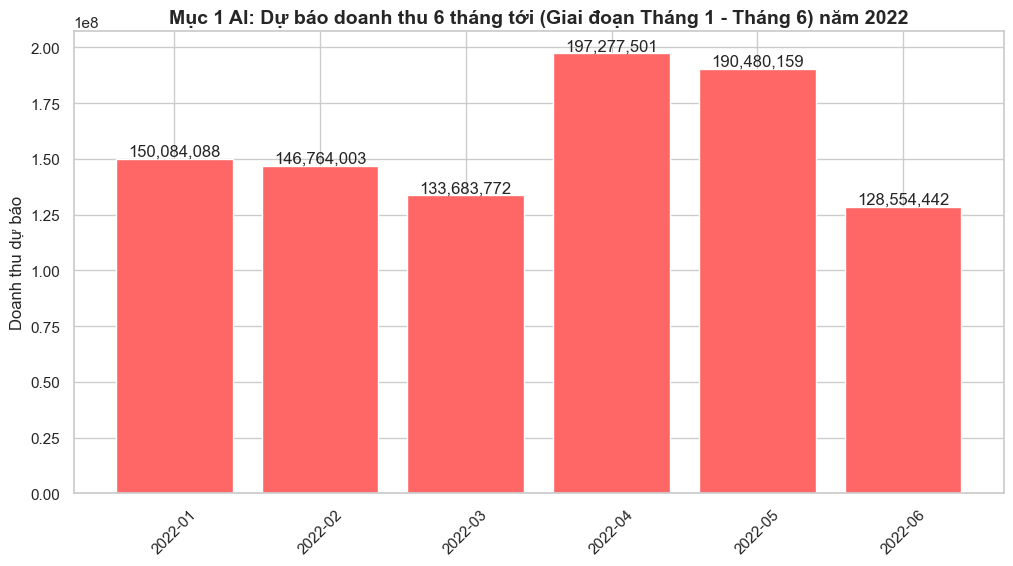

In [13]:
plt.figure(figsize=(12, 6))

# Đảo ngược log transform
forecast_future['yhat_orig'] = np.expm1(forecast_future['yhat'])

monthly_sales = forecast_future.groupby("Month")["yhat_orig"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.bar(monthly_sales.index, monthly_sales.values, color='#FF6666')

for i, v in enumerate(monthly_sales.values):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.title("Mục 1 AI: Dự báo doanh thu 6 tháng tới (Giai đoạn Tháng 1 - Tháng 6) năm 2022", fontsize=14, fontweight='bold')
plt.ylabel("Doanh thu dự báo")
plt.xticks(rotation=45)

plt.show()

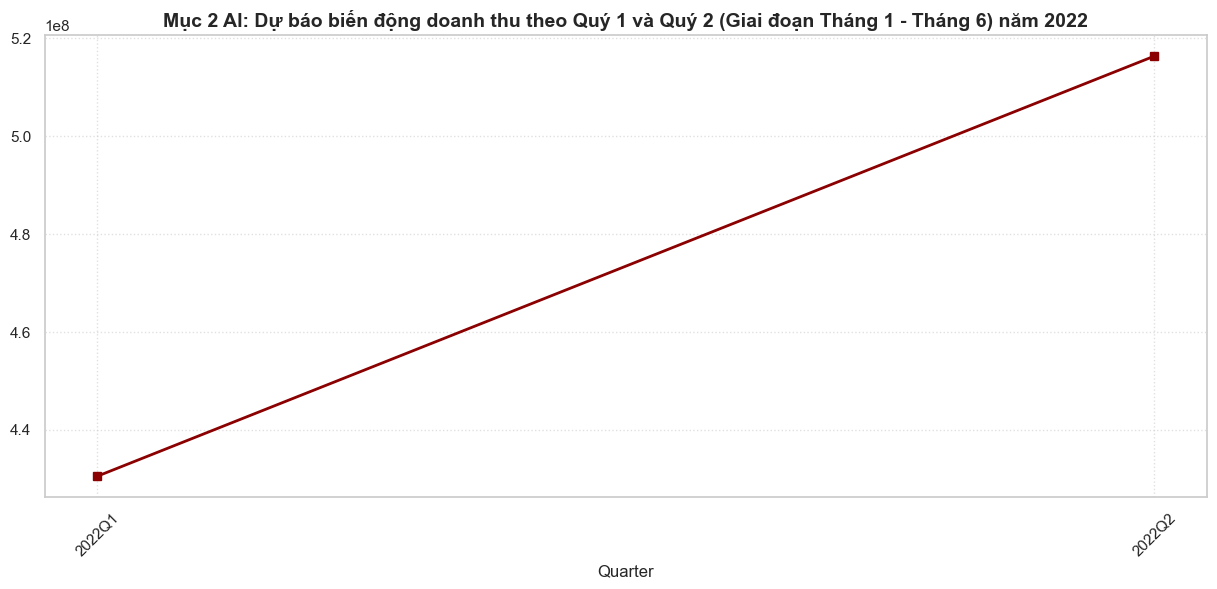

In [14]:
# Tạo cột Quarter dựa trên ngày
forecast_future["Quarter"] = forecast_future["ds"].dt.to_period("Q")
plt.figure(figsize=(15, 6))
q_ai = forecast_future.groupby("Quarter")["yhat_orig"].sum()
q_ai.index = q_ai.index.astype(str)
q_ai.plot(kind='line', marker='s', color='darkred', linewidth=2)

plt.xticks(range(len(q_ai.index)), q_ai.index, rotation=45)
plt.title("Mục 2 AI: Dự báo biến động doanh thu theo Quý 1 và Quý 2 (Giai đoạn Tháng 1 - Tháng 6) năm 2022", fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

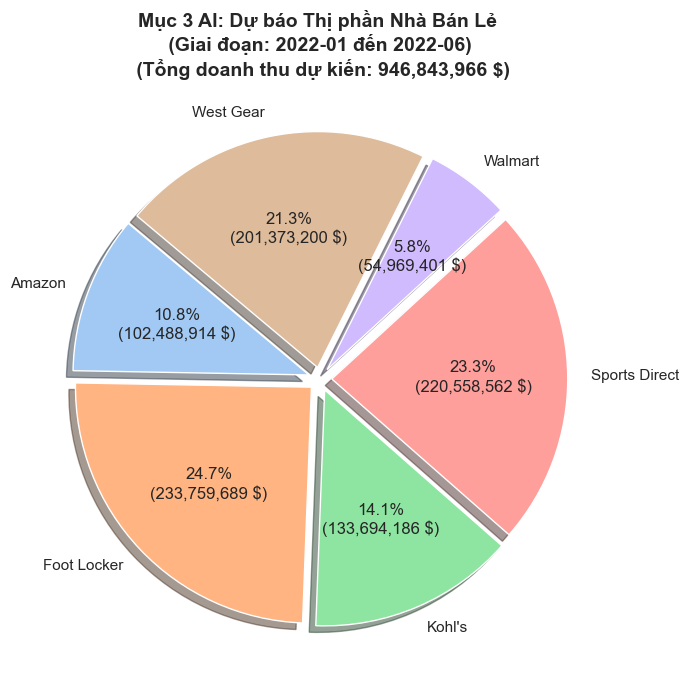

In [15]:
# 1. Tính tổng doanh thu dự báo của TOÀN BỘ 6 tháng tới (Tổng yhat)
total_rev_6m = forecast_future["yhat_orig"].sum()

# 2. Tính tỷ trọng Retailer từ dữ liệu lịch sử (năm gần nhất)
base_ratio = df[df["Year"] == df["Year"].max()].groupby("Retailer")["Total Sales"].sum()
base_ratio = base_ratio / base_ratio.sum()

# 3. Phân bổ tổng doanh thu dự báo 6 tháng cho từng Retailer
retailer_forecast_total = base_ratio * total_rev_6m

# 4. Vẽ biểu đồ Pie duy nhất cho tổng thể 6 tháng
plt.figure(figsize=(10, 7))
colors = sns.color_palette("pastel")
explode = [0.05] * len(retailer_forecast_total) # Tạo hiệu ứng tách nhẹ các miếng bánh

plt.pie(retailer_forecast_total, 
        labels=retailer_forecast_total.index, 
        autopct=lambda pct: f'{pct:.1f}%\n({pct*total_rev_6m/100:,.0f} $)',
        startangle=140, 
        colors=colors,
        explode=explode,
        shadow=True)

# Lấy thông tin khoảng thời gian dự báo để làm tiêu đề
start_m = forecast_future["Month"].min()
end_m = forecast_future["Month"].max()

plt.title(f"Mục 3 AI: Dự báo Thị phần Nhà Bán Lẻ \n (Giai đoạn: {start_m} đến {end_m}) \n (Tổng doanh thu dự kiến: {total_rev_6m:,.0f} $)", 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

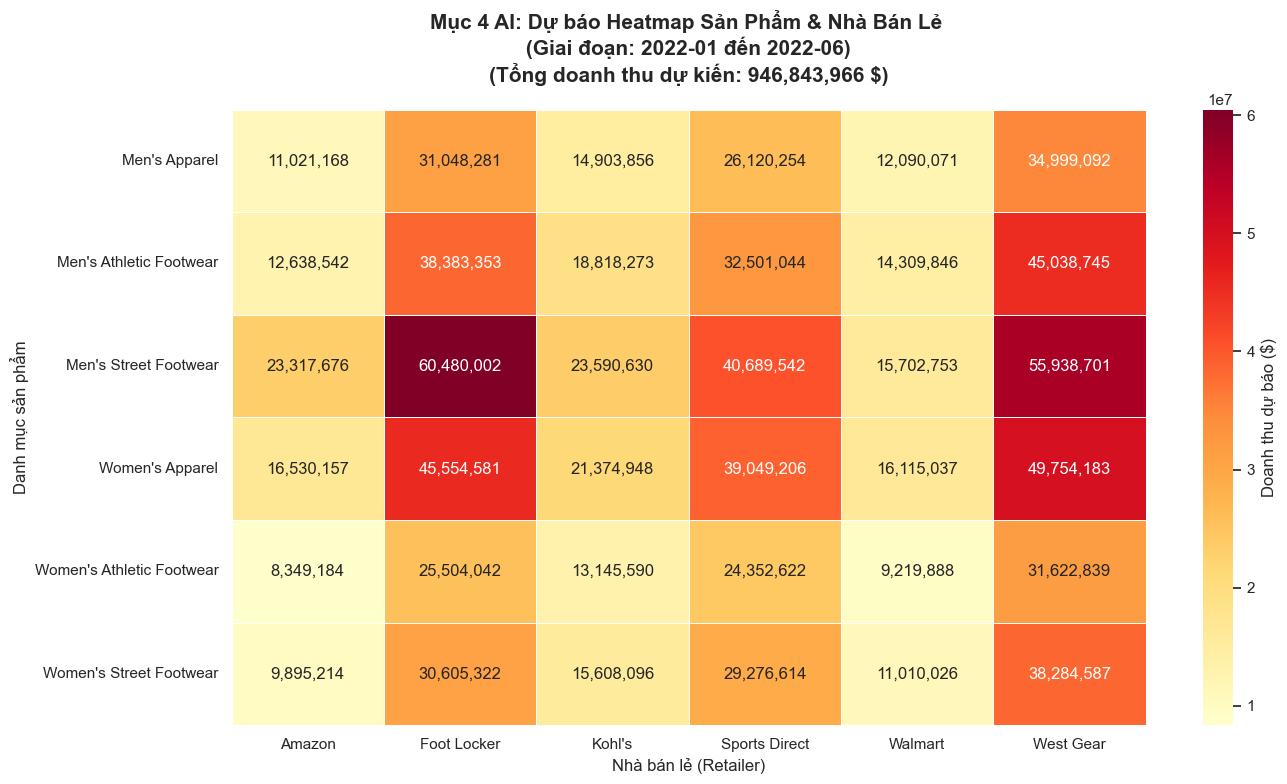

In [16]:
# 1. Tính TỔNG doanh thu dự báo của toàn bộ 6 tháng tới (Tổng yhat)
total_rev_6m = forecast_future["yhat_orig"].sum()

# 2. Tạo bảng tỷ trọng dựa trên dữ liệu lịch sử (Tổng doanh thu từng ô / Tổng doanh thu toàn bộ)
current_ratio = pd.pivot_table(
    df,
    values="Total Sales",
    index="Product",
    columns="Retailer",
    aggfunc="sum"
).fillna(0)

current_ratio = current_ratio / current_ratio.values.sum()

# 3. Phân bổ tổng doanh thu 6 tháng vào bảng Heatmap
forecast_distribution = current_ratio * total_rev_6m

# 4. Vẽ Heatmap duy nhất
plt.figure(figsize=(14, 8))
sns.heatmap(forecast_distribution, 
            annot=True, 
            fmt=",.0f", 
            cmap="YlOrRd", 
            cbar_kws={'label': 'Doanh thu dự báo ($)'},
            linewidths=.5)

# Lấy thông tin khoảng thời gian để hiển thị tiêu đề
start_m = forecast_future["Month"].min()
end_m = forecast_future["Month"].max()

plt.title(f"Mục 4 AI: Dự báo Heatmap Sản Phẩm & Nhà Bán Lẻ \n (Giai đoạn: {start_m} đến {end_m}) \n(Tổng doanh thu dự kiến: {total_rev_6m:,.0f} $)", 
          fontsize=15, fontweight='bold', pad=20)

plt.xlabel("Nhà bán lẻ (Retailer)", fontsize=12)
plt.ylabel("Danh mục sản phẩm", fontsize=12)
plt.tight_layout()
plt.show()

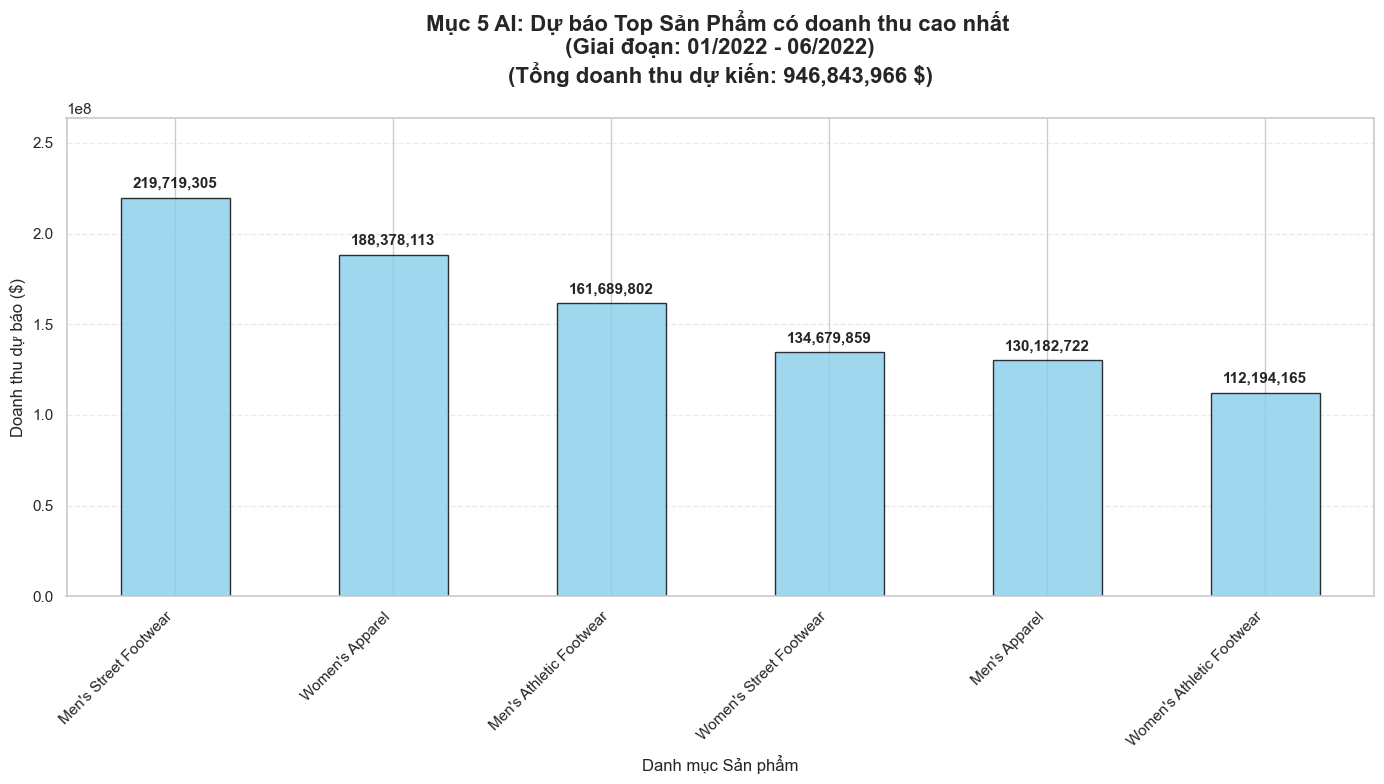

In [17]:
# 1. Tính TỔNG doanh thu dự báo của TOÀN BỘ 6 tháng tới
total_rev_6m = forecast_future["yhat_orig"].sum()

# 2. Tính tỷ trọng doanh thu của từng sản phẩm dựa trên dữ liệu lịch sử
base_product_ratio = df.groupby("Product")["Total Sales"].sum() / df["Total Sales"].sum()

# 3. Phân bổ tổng doanh thu 6 tháng cho từng sản phẩm
product_forecast_6m = (base_product_ratio * total_rev_6m).sort_values(ascending=False)

# 4. Vẽ biểu đồ cột đứng duy nhất
plt.figure(figsize=(14, 8))
ax = product_forecast_6m.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)

# --- THÊM NHÃN SỐ LIỆU LÊN ĐẦU CỘT ---
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold')

# 5. Trang trí biểu đồ
# Lấy thông tin tháng bắt đầu và kết thúc để tiêu đề chuyên nghiệp hơn
start_date = forecast_future["ds"].min().strftime('%m/%Y')
end_date = forecast_future["ds"].max().strftime('%m/%Y')

plt.title(f"Mục 5 AI: Dự báo Top Sản Phẩm có doanh thu cao nhất \n (Giai đoạn: {start_date} - {end_date}) \n(Tổng doanh thu dự kiến: {total_rev_6m:,.0f} $)", 
          fontsize=16, fontweight='bold', pad=25)

plt.xlabel("Danh mục Sản phẩm", fontsize=12)
plt.ylabel("Doanh thu dự báo ($)", fontsize=12)

# Nới rộng trục Y để không bị chạm nhãn
plt.ylim(0, product_forecast_6m.max() * 1.2)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

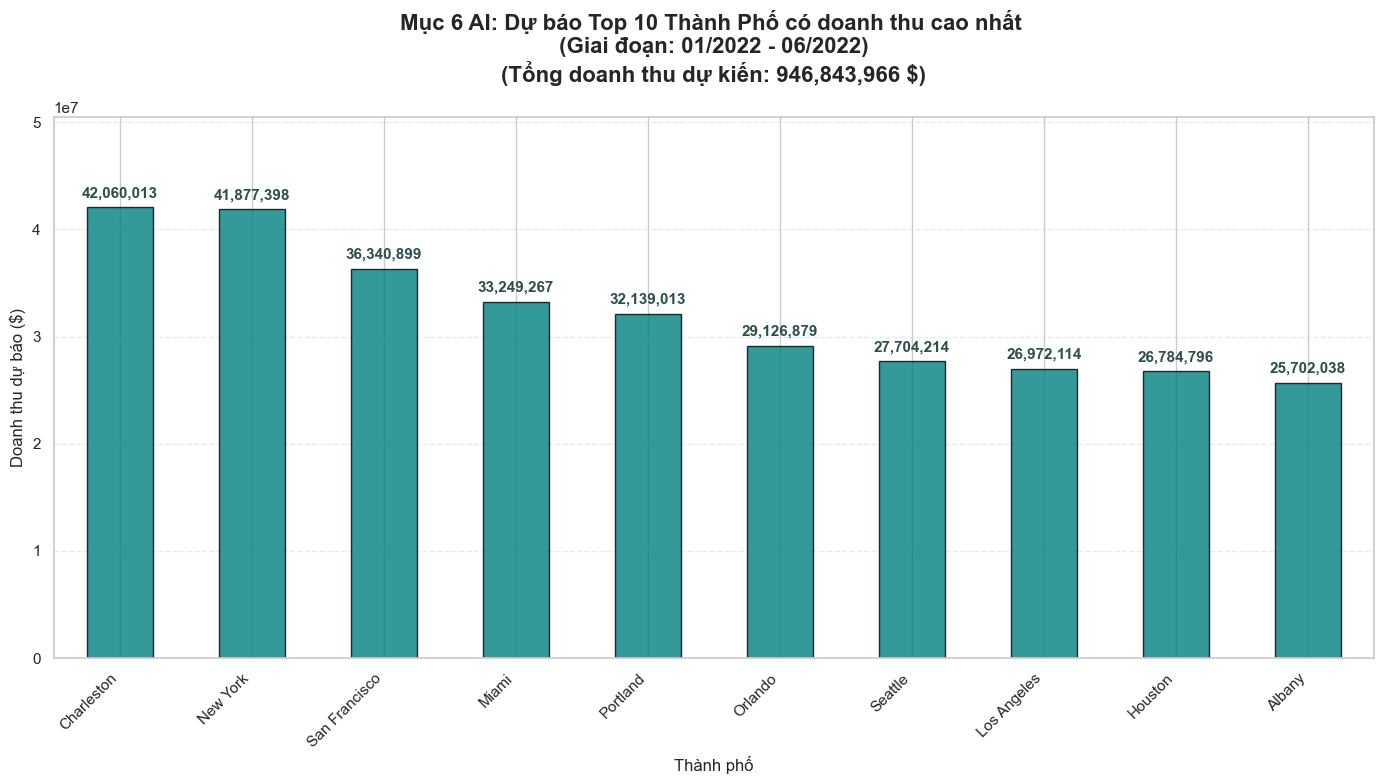

In [18]:
# 1. Tính TỔNG doanh thu dự báo của TOÀN BỘ 6 tháng tới
total_rev_6m = forecast_future["yhat_orig"].sum()

# 2. Tính tỷ trọng doanh thu của từng thành phố dựa trên dữ liệu lịch sử
base_city_ratio = df.groupby("City")["Total Sales"].sum() / df["Total Sales"].sum()

# 3. Phân bổ tổng doanh thu 6 tháng và lọc lấy Top 10
city_forecast_6m = (base_city_ratio * total_rev_6m).sort_values(ascending=False).head(10)

# 4. Vẽ biểu đồ cột đứng duy nhất
plt.figure(figsize=(14, 8))
ax = city_forecast_6m.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)

# --- THÊM NHÃN SỐ LIỆU TRÊN ĐỈNH CỘT ---
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5, fontsize=11, fontweight='bold', color='darkslategray')

# 5. Trang trí biểu đồ
# Tự động lấy khoảng thời gian từ dữ liệu dự báo
start_date = forecast_future["ds"].min().strftime('%m/%Y')
end_date = forecast_future["ds"].max().strftime('%m/%Y')

plt.title(f"Mục 6 AI: Dự báo Top 10 Thành Phố có doanh thu cao nhất \n (Giai đoạn: {start_date} - {end_date}) \n(Tổng doanh thu dự kiến: {total_rev_6m:,.0f} $)", 
          fontsize=16, fontweight='bold', pad=25)

plt.xlabel("Thành phố", fontsize=12)
plt.ylabel("Doanh thu dự báo ($)", fontsize=12)

# Nới rộng trục Y để hiển thị nhãn số đẹp hơn
plt.ylim(0, city_forecast_6m.max() * 1.2)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

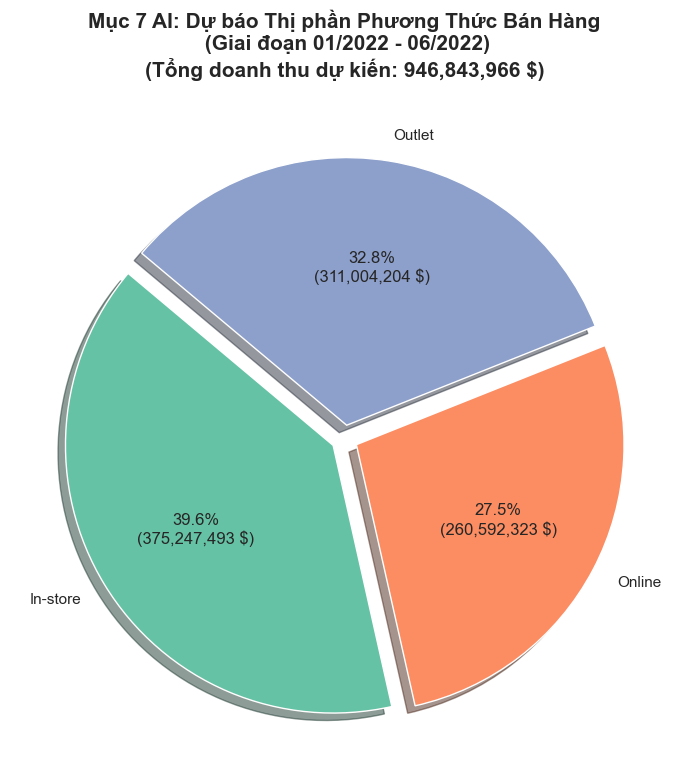

In [19]:
# 1. Tính tổng doanh thu dự báo của TOÀN BỘ 6 tháng tới
total_rev_6m = forecast_future["yhat_orig"].sum()

# 2. Tính tỷ trọng phương thức bán hàng từ dữ liệu lịch sử
base_method_ratio = df.groupby("Sales Method")["Total Sales"].sum() / df["Total Sales"].sum()

# 3. Phân bổ tổng doanh thu 6 tháng cho từng phương thức
method_forecast_total = base_method_ratio * total_rev_6m

# 4. Vẽ biểu đồ tròn (Pie Chart) duy nhất
plt.figure(figsize=(10, 8))
colors = sns.color_palette("Set2")
explode_value = [0.05] * len(base_method_ratio)

plt.pie(method_forecast_total, 
        labels=method_forecast_total.index, 
        autopct=lambda pct: f'{pct:.1f}%\n({pct*total_rev_6m/100:,.0f} $)',
        startangle=140, 
        colors=colors,
        explode=explode_value, 
        shadow=True)

# Lấy khoảng thời gian để hiển thị tiêu đề cho chính xác
start_date = forecast_future["ds"].min().strftime('%m/%Y')
end_date = forecast_future["ds"].max().strftime('%m/%Y')

plt.title(f"Mục 7 AI: Dự báo Thị phần Phương Thức Bán Hàng\n (Giai đoạn {start_date} - {end_date})\n(Tổng doanh thu dự kiến: {total_rev_6m:,.0f} $)", 
          fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()